# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"
df = pd.read_csv(fp)

## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

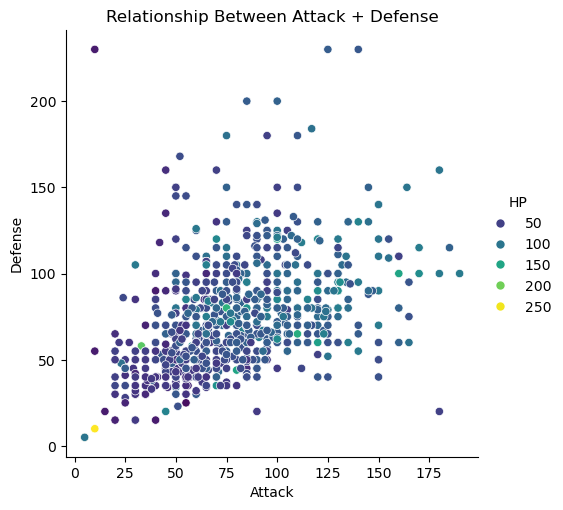

In [2]:
sns.relplot(
    data=df,
    x="Attack",
    y="Defense",
    hue="HP",
    palette="viridis"
)
plt.title("Relationship Between Attack + Defense")
plt.show()

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

After creating the visualizaton of the relationship between Attack and Defense, I quickly observed that Pokemon with higher stats in "attack" additionally had higher defense which meant that they were overall more stronger. Furthermore, we can see the difference in strength from different level of stats, such as HP appearing at different ranges based on Attack and Defense. 


## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

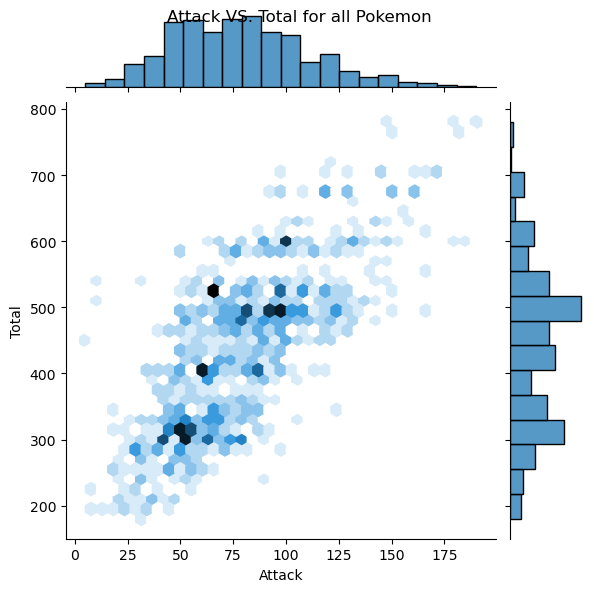

In [3]:
# Your code here . . .

sns.jointplot(
    data=df,
    x="Attack",
    y="Total",
    kind="hex",      
    gridsize=35     
)

plt.suptitle("Attack VS. Total for all Pokemon")
plt.show()

From the plot, I observed that the hexbin visualization demonstrates the relationship between Attack and Total stats. Based on the types of Pokemon, their skill level can fall into certain "buckets" or ranges. The darker colour hexagons signifies vast population of particular Pokemon. Furthermore, the histogram on the X and Y-axis showcases the distribution between Attack and Total values separately. 

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

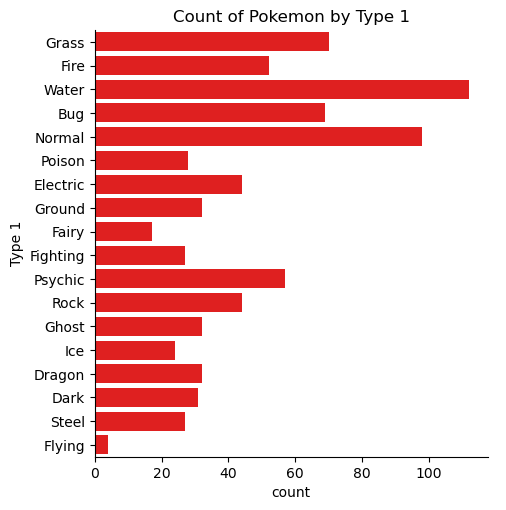

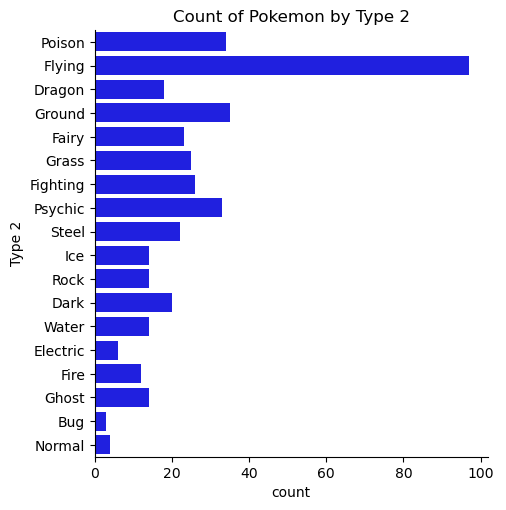

In [4]:
# Your code here . . .

sns.catplot(
    data=df,
    y="Type 1",
    kind="count",
    color="red"
)

plt.title("Count of Pokemon by Type 1")
plt.show()


sns.catplot(
    data=df,
    y="Type 2",
    kind="count",
    color="blue"
)

plt.title("Count of Pokemon by Type 2")
plt.show()


For Type 1, it's most common type is Water, followed by Normal and Grass. The most rare Pokemon is Flying. 

On the other hand, Type 2 has Flying Pokemon as common, then followed by Poison and Ground. In terms of rarity, it is Bug and Normal Pokemon. 

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your question(s) . . .

Which Pokemon Types has the highest average attack and defense?
Which Pokemon Types have the highest average speed?
Are newer generations of Pokemon tend to be stronger than the older ones? Or Vice Vera?

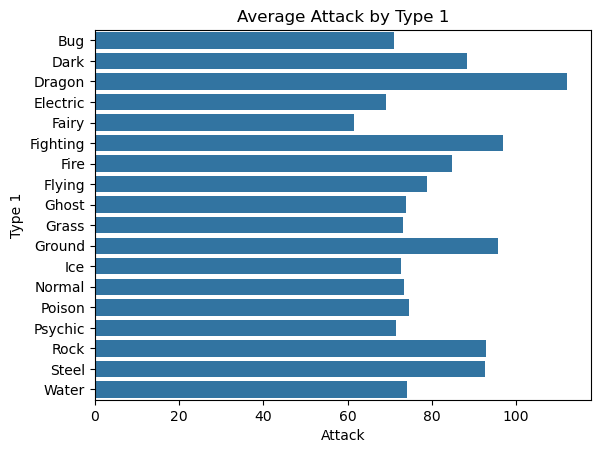

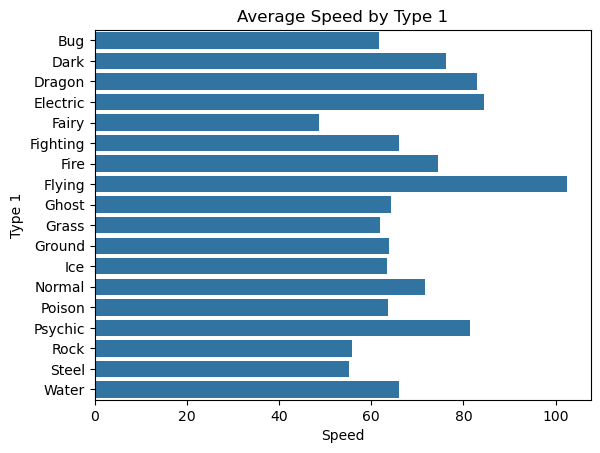

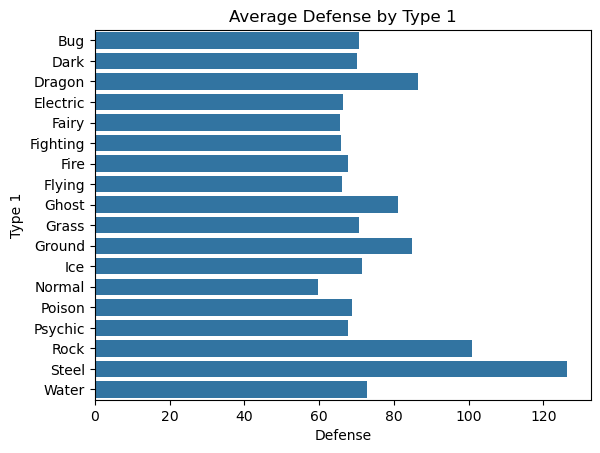

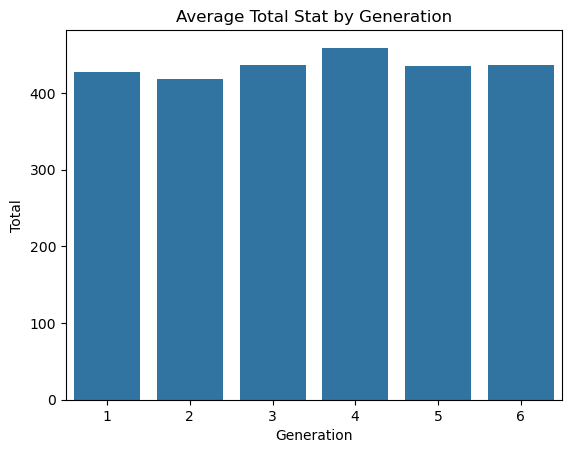

In [5]:
# Your code here . . .

type1_means = df.groupby("Type 1")[["Attack", "Defense"]].mean().reset_index()

sns.barplot(data=type1_means, y="Type 1", x="Attack")
plt.title("Average Attack by Type 1")
plt.show()


type1_speed = df.groupby("Type 1")["Speed"].mean().reset_index()

sns.barplot(data=type1_speed, y="Type 1", x="Speed")
plt.title("Average Speed by Type 1")
plt.show()


sns.barplot(data=type1_means, y="Type 1", x="Defense")
plt.title("Average Defense by Type 1")
plt.show()



gen_total = df.groupby("Generation")["Total"].mean().reset_index()

sns.barplot(data=gen_total, x="Generation", y="Total")
plt.title("Average Total Stat by Generation")
plt.show()

